In [1]:
# ============================================
# HR Attrition ETL Pipeline & Analysis
# Author: Gobind Kumar
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Lucky\Documents\Downloads
['.ipynb_checkpoints', 'HR_Attrition_ETL_Analysis.ipynb']


In [8]:
# ============================================
# STEP 1: EXTRACT — Load the dataset
# ============================================

df = pd.read_csv(r"C:\Users\Lucky\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("✅ Data extracted successfully!")
print(f"📊 Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

✅ Data extracted successfully!
📊 Dataset shape: 1470 rows and 35 columns

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
# ============================================
# STEP 2: TRANSFORM — Explore & Clean Data
# ============================================

# 2a. Check basic info
print("📋 Dataset Info:")
print(f"Total Employees: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# 2b. Check missing values
print("\n🔍 Missing Values:")
print(df.isnull().sum().sum(), "total missing values found")

# 2c. Check attrition distribution
print("\n👥 Attrition Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {round(df['Attrition'].value_counts()['Yes'] / len(df) * 100, 2)}%")

📋 Dataset Info:
Total Employees: 1470
Total Columns: 35

🔍 Missing Values:
0 total missing values found

👥 Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [10]:
# 2d. Drop useless columns (same value for all rows)
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

# 2e. Convert Attrition to numeric (Yes=1, No=0)
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 2f. Feature Engineering — Add Age Group column
def age_group(age):
    if age <= 30:
        return 'Young'
    elif age <= 45:
        return 'Mid'
    else:
        return 'Senior'

df['Age_Group'] = df['Age'].apply(age_group)

print("✅ Transform complete!")
print(f"New shape: {df.shape}")
print("\nAge Group distribution:")
print(df['Age_Group'].value_counts())

✅ Transform complete!
New shape: (1470, 34)

Age Group distribution:
Age_Group
Mid       811
Young     386
Senior    273
Name: count, dtype: int64


In [11]:
# ============================================
# STEP 3: LOAD — Save clean data to SQLite DB
# ============================================

# Create a database connection
conn = sqlite3.connect('hr_attrition.db')

# Save dataframe to SQL table
df.to_sql('employees', conn, if_exists='replace', index=False)

print("✅ Data loaded to SQLite database!")
print("📁 Database file: hr_attrition.db")
print(f"💾 Total records saved: {len(df)}")

✅ Data loaded to SQLite database!
📁 Database file: hr_attrition.db
💾 Total records saved: 1470


In [12]:
# ============================================
# STEP 4: SQL ANALYSIS
# ============================================

# Q1: Attrition by Department
print("📊 Q1: Attrition Rate by Department")
query1 = """
SELECT Department,
       COUNT(*) as Total_Employees,
       SUM(Attrition_Num) as Employees_Left,
       ROUND(SUM(Attrition_Num) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM employees
GROUP BY Department
ORDER BY Attrition_Rate DESC
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

📊 Q1: Attrition Rate by Department
               Department  Total_Employees  Employees_Left  Attrition_Rate
0                   Sales              446              92           20.63
1         Human Resources               63              12           19.05
2  Research & Development              961             133           13.84


In [13]:
# Q2: Attrition by Age Group
print("📊 Q2: Attrition Rate by Age Group")
query2 = """
SELECT Age_Group,
       COUNT(*) as Total_Employees,
       SUM(Attrition_Num) as Employees_Left,
       ROUND(SUM(Attrition_Num) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM employees
GROUP BY Age_Group
ORDER BY Attrition_Rate DESC
"""
result2 = pd.read_sql_query(query2, conn)
print(result2)

📊 Q2: Attrition Rate by Age Group
  Age_Group  Total_Employees  Employees_Left  Attrition_Rate
0     Young              386             100           25.91
1       Mid              811             103           12.70
2    Senior              273              34           12.45


In [14]:
# Q3: Attrition by Overtime
print("📊 Q3: Impact of Overtime on Attrition")
query3 = """
SELECT OverTime,
       COUNT(*) as Total_Employees,
       SUM(Attrition_Num) as Employees_Left,
       ROUND(SUM(Attrition_Num) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM employees
GROUP BY OverTime
ORDER BY Attrition_Rate DESC
"""
result3 = pd.read_sql_query(query3, conn)
print(result3)

📊 Q3: Impact of Overtime on Attrition
  OverTime  Total_Employees  Employees_Left  Attrition_Rate
0      Yes              416             127           30.53
1       No             1054             110           10.44


In [15]:
# Q4: Attrition by Job Role
print("📊 Q4: Attrition Rate by Job Role")
query4 = """
SELECT JobRole,
       COUNT(*) as Total_Employees,
       SUM(Attrition_Num) as Employees_Left,
       ROUND(SUM(Attrition_Num) * 100.0 / COUNT(*), 2) as Attrition_Rate
FROM employees
GROUP BY JobRole
ORDER BY Attrition_Rate DESC
LIMIT 5
"""
result4 = pd.read_sql_query(query4, conn)
print(result4)

📊 Q4: Attrition Rate by Job Role
                 JobRole  Total_Employees  Employees_Left  Attrition_Rate
0   Sales Representative               83              33           39.76
1  Laboratory Technician              259              62           23.94
2        Human Resources               52              12           23.08
3        Sales Executive              326              57           17.48
4     Research Scientist              292              47           16.10


In [16]:
# Q5: Monthly Income vs Attrition
print("📊 Q5: Average Salary - Stayed vs Left")
query5 = """
SELECT Attrition,
       ROUND(AVG(MonthlyIncome), 2) as Avg_Monthly_Income,
       ROUND(AVG(YearsAtCompany), 2) as Avg_Years_At_Company,
       COUNT(*) as Total
FROM employees
GROUP BY Attrition
"""
result5 = pd.read_sql_query(query5, conn)
print(result5)

📊 Q5: Average Salary - Stayed vs Left
  Attrition  Avg_Monthly_Income  Avg_Years_At_Company  Total
0        No             6832.74                  7.37   1233
1       Yes             4787.09                  5.13    237


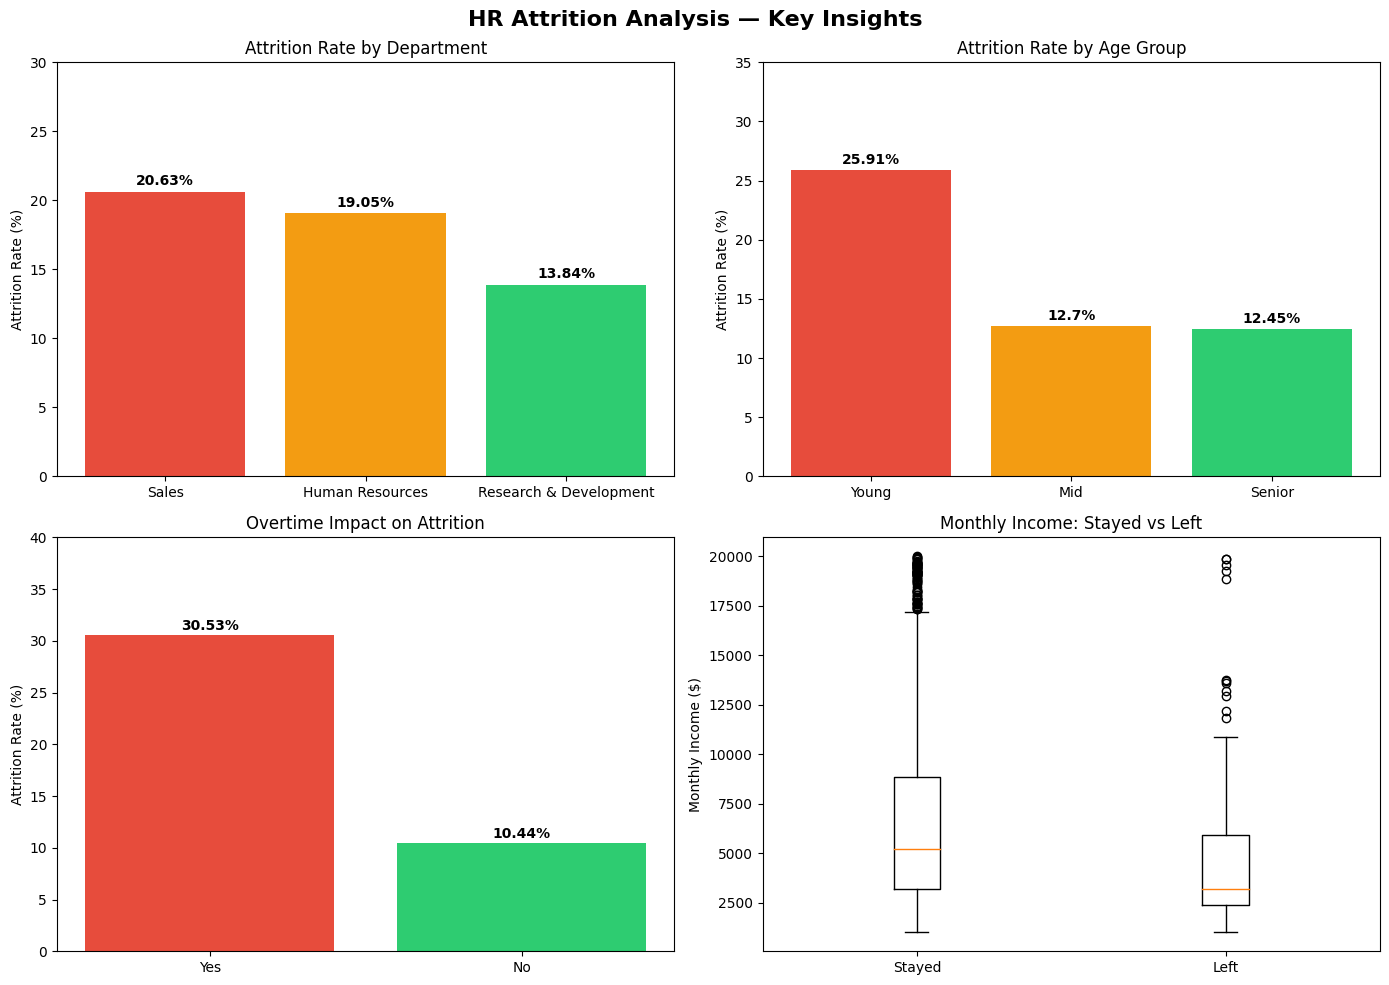

✅ Charts saved as hr_attrition_insights.png


In [17]:
# ============================================
# STEP 5: VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Attrition Analysis — Key Insights', 
             fontsize=16, fontweight='bold')

# Chart 1: Attrition by Department
axes[0,0].bar(result1['Department'], result1['Attrition_Rate'], 
              color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0,0].set_title('Attrition Rate by Department')
axes[0,0].set_ylabel('Attrition Rate (%)')
axes[0,0].set_ylim(0, 30)
for i, v in enumerate(result1['Attrition_Rate']):
    axes[0,0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Chart 2: Attrition by Age Group
colors2 = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0,1].bar(result2['Age_Group'], result2['Attrition_Rate'], color=colors2)
axes[0,1].set_title('Attrition Rate by Age Group')
axes[0,1].set_ylabel('Attrition Rate (%)')
axes[0,1].set_ylim(0, 35)
for i, v in enumerate(result2['Attrition_Rate']):
    axes[0,1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Chart 3: Overtime Impact
axes[1,0].bar(result3['OverTime'], result3['Attrition_Rate'],
              color=['#e74c3c', '#2ecc71'])
axes[1,0].set_title('Overtime Impact on Attrition')
axes[1,0].set_ylabel('Attrition Rate (%)')
axes[1,0].set_ylim(0, 40)
for i, v in enumerate(result3['Attrition_Rate']):
    axes[1,0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Chart 4: Salary vs Attrition
stayed = df[df['Attrition']=='No']['MonthlyIncome']
left = df[df['Attrition']=='Yes']['MonthlyIncome']
axes[1,1].boxplot([stayed, left], labels=['Stayed', 'Left'])
axes[1,1].set_title('Monthly Income: Stayed vs Left')
axes[1,1].set_ylabel('Monthly Income ($)')

plt.tight_layout()
plt.savefig('hr_attrition_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as hr_attrition_insights.png")

In [18]:
# ============================================
# STEP 6: KEY BUSINESS INSIGHTS SUMMARY
# ============================================

print("HR ATTRITION ANALYSIS — KEY FINDINGS")
print("=" * 45)

print("""
📊 Overall Attrition Rate: 16.12%
   (Above healthy industry average of 10-12%)

🏢 By Department:
   → Sales: 20.63% (HIGHEST - needs immediate attention)
   → Human Resources: 19.05%
   → R&D: 13.84% (healthiest)

👥 By Age Group:
   → Young (<30): 25.91% (CRITICAL - 1 in 4 leaving)
   → Mid (31-45): 12.70%
   → Senior (45+): 12.45%

⏰ Overtime Impact:
   → With Overtime: 30.53% (3x higher risk!)
   → Without Overtime: 10.44%

💼 Highest Risk Job Roles:
   → Sales Representative: 39.76% (CRITICAL)
   → Laboratory Technician: 23.94%
   → Human Resources: 23.08%

💰 Salary Impact:
   → Employees who stayed: $6,832/month avg
   → Employees who left: $4,787/month avg
   → Employees who left earned 30% LESS

🎯 Top Recommendations:
   1. Review compensation for Sales & junior roles
   2. Implement overtime policies to reduce burnout
   3. Create career development programs for young staff
""")

HR ATTRITION ANALYSIS — KEY FINDINGS

📊 Overall Attrition Rate: 16.12%
   (Above healthy industry average of 10-12%)

🏢 By Department:
   → Sales: 20.63% (HIGHEST - needs immediate attention)
   → Human Resources: 19.05%
   → R&D: 13.84% (healthiest)

👥 By Age Group:
   → Young (<30): 25.91% (CRITICAL - 1 in 4 leaving)
   → Mid (31-45): 12.70%
   → Senior (45+): 12.45%

⏰ Overtime Impact:
   → With Overtime: 30.53% (3x higher risk!)
   → Without Overtime: 10.44%

💼 Highest Risk Job Roles:
   → Sales Representative: 39.76% (CRITICAL)
   → Laboratory Technician: 23.94%
   → Human Resources: 23.08%

💰 Salary Impact:
   → Employees who stayed: $6,832/month avg
   → Employees who left: $4,787/month avg
   → Employees who left earned 30% LESS

🎯 Top Recommendations:
   1. Review compensation for Sales & junior roles
   2. Implement overtime policies to reduce burnout
   3. Create career development programs for young staff

